In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. MEMBACA DATASET KECIL (STUDENT PERFORMANCE)
# ==========================================
# Membaca file CSV yang ringan (Sangat aman untuk GitHub)
data = pd.read_csv('score.csv')

print("--- 5 Data Pertama Student Dataset ---")
print(data.head())
print("\n" + "="*40 + "\n")

--- 5 Data Pertama Student Dataset ---
   Hours  Scores
0    2.5      21
1    5.1      47
2    3.2      27
3    8.5      75
4    3.5      30




In [17]:
# ==========================================
# 2. PEMBAGIAN DATA (TRAIN & TEST SPLIT)
# ==========================================
# X = Jam Belajar (Hours), y = Nilai Ujian (Scores)
X = data[['Hours']]
y = data['Scores']

# Membagi data menjadi 80% data latih dan 20% data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latih: {len(X_train)}")
print(f"Jumlah data uji: {len(X_test)}")
print("\n" + "="*40 + "\n")

Jumlah data latih: 20
Jumlah data uji: 5




In [18]:
# ==========================================
# 3. PELATIHAN MODEL (TRAINING)
# ==========================================
model_regresi = LinearRegression()
model_regresi.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
# ==========================================
# 4. PREDIKSI DAN EVALUASI
# ==========================================
y_pred = model_regresi.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Hasil Evaluasi Model Performa Siswa ---")
print(f"Koefisien (Slope): {model_regresi.coef_[0]:.2f}")
print(f"Intercept (Konstanta): {model_regresi.intercept_:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score: {r2:.2f} (Model menjelaskan {(r2*100):.1f}% variasi data)")
print("\n" + "="*40 + "\n")

--- Hasil Evaluasi Model Performa Siswa ---
Koefisien (Slope): 9.68
Intercept (Konstanta): 2.83
Mean Squared Error (MSE): 18.94
R-squared Score: 0.97 (Model menjelaskan 96.8% variasi data)




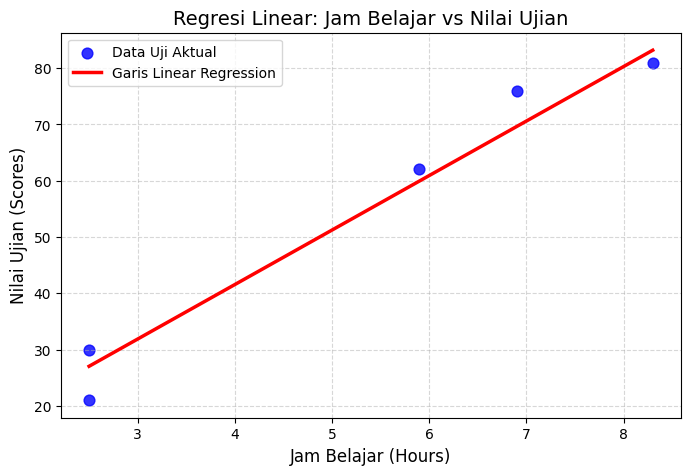

In [20]:
# ==========================================
# 5. VISUALISASI HASIL REGRESI
# ==========================================
plt.figure(figsize=(8, 5))

# Plot titik data asli hasil pengujian (Warna Biru)
plt.scatter(X_test, y_test, color='blue', alpha=0.8, s=60, label='Data Uji Aktual')

# Mengurutkan data X_test agar tarikan garis regresi rapi dan lurus
X_test_sorted = X_test.sort_values(by='Hours')
y_pred_sorted = model_regresi.predict(X_test_sorted)

# Plot garis prediksi Linear Regression (Warna Merah)
plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2.5, label='Garis Linear Regression')

plt.title('Regresi Linear: Jam Belajar vs Nilai Ujian', fontsize=14)
plt.xlabel('Jam Belajar (Hours)', fontsize=12)
plt.ylabel('Nilai Ujian (Scores)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Menampilkan grafik di VS Code
plt.show()